In [1]:
import csv
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input, Concatenate, Dot, Lambda

In [2]:
""" from tqdm.notebook import tqdm
# Read data from text
with open('train_snli.txt') as file:
    data = file.readlines()

# prepare csv file
with open('data.csv', 'w', newline='') as csvfile:
    filenames = ['source_txt', 'plagiarism_txt', 'label']
    writer = csv.DictWriter(csvfile, fieldnames=filenames)

    writer.writeheader()
    for line in tqdm(data):
        parts = line.strip().split('\t')
        source_txt = parts[0]
        plagiarishm_txt = parts[1]
        label = int(parts[2])

        writer.writerow({
            'source_txt': source_txt,
            'plagiarism_txt': plagiarishm_txt,
            'label': label
        })
print('CSV file created successfully...') """

" from tqdm.notebook import tqdm\n# Read data from text\nwith open('train_snli.txt') as file:\n    data = file.readlines()\n\n# prepare csv file\nwith open('data.csv', 'w', newline='') as csvfile:\n    filenames = ['source_txt', 'plagiarism_txt', 'label']\n    writer = csv.DictWriter(csvfile, fieldnames=filenames)\n\n    writer.writeheader()\n    for line in tqdm(data):\n        parts = line.strip().split('\t')\n        source_txt = parts[0]\n        plagiarishm_txt = parts[1]\n        label = int(parts[2])\n\n        writer.writerow({\n            'source_txt': source_txt,\n            'plagiarism_txt': plagiarishm_txt,\n            'label': label\n        })\nprint('CSV file created successfully...') "

In [3]:
df = pd.read_csv('file2_plag.csv')

In [4]:
df.head()

,Unnamed: 0,source_txt,plagiarism_txt,label
0,0,Full Terms & Conditions of access and use can ...,"Received June 28, 2019, accepted July 13, 2019...",0
1,1,IEEE TRANSACTIONS ON AUTOMATION SCIENCE AND EN...,"Received June 28, 2019, accepted July 13, 2019...",1
2,2,979-8-3503-6370-8/24/$31.00©2024 IEEE \n123 \...,"Received June 28, 2019, accepted July 13, 2019...",1
3,3,Optimal Electric Vehicle Charging Station\nPla...,"Received June 28, 2019, accepted July 13, 2019...",0
4,4,Siting of Electric Vehicle Charging Stations B...,"Received June 28, 2019, accepted July 13, 2019...",1


In [5]:
df.isnull().sum()

Unnamed: 0        0
source_txt        0
plagiarism_txt    0
label             0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.dropna(inplace=True)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.shape)

Unnamed: 0        0
source_txt        0
plagiarism_txt    0
label             0
dtype: int64
0
(15, 4)


<Axes: xlabel='label'>

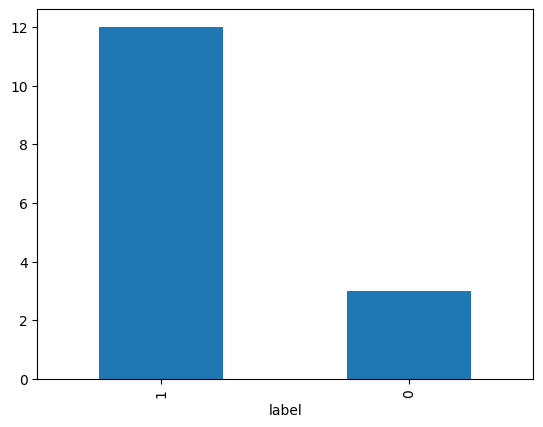

In [10]:
df['label'].value_counts().plot(kind='bar')

In [11]:
print(df['source_txt'][1])
print(df['plagiarism_txt'][1])

IEEE TRANSACTIONS ON AUTOMATION SCIENCE AND ENGINEERING, VOL. 21, NO. 3, JULY 2024
4261
Optimal Planning of Fast EV Charging Stations
in a Coupled Transportation and Electrical
Power Distribution Network
Aastha Kapoor , Member, IEEE, Viresh S. Patel , Student Member, IEEE,
Ankush Sharma , Senior Member, IEEE, and Abheejeet Mohapatra , Member, IEEE
Abstract— Electric Vehicles (EVs) can effectively mitigate
global warming issues while ensuring energy security, when
compared
with
conventional
fuel-based
vehicles.
Therefore,
proper
planning
and
development
of
charging
infrastruc-
ture are essential to promote EVs. This paper proposes a
multi-objective formulation to determine fast charging stations’
optimal placement and sizing on intra-city corridors in a cou-
pled transportation and Electrical Power Distribution Network
(EPDN). The proposed formulation does a distance-based map-
ping between all transportation and EPDN nodes for precisely
observing the impact of EV charging on EPDN. The 

In [12]:
import string


def preprocess_text(text):
    if isinstance(text, str):
        # Remove punctuation
        text = text.translate(str.maketrans("", "", string.punctuation))
        # Convert to lowercase
        text = text.lower()
    return text

In [13]:
df['source_txt'] = df['source_txt'].apply(preprocess_text)
df['plagiarism_txt'] = df['plagiarism_txt'].apply(preprocess_text)

In [14]:
df['source_txt'][1]

'ieee transactions on automation science and engineering vol 21 no 3 july 2024\n4261\noptimal planning of fast ev charging stations\nin a coupled transportation and electrical\npower distribution network\naastha kapoor  member ieee viresh s patel  student member ieee\nankush sharma  senior member ieee and abheejeet mohapatra  member ieee\nabstract— electric vehicles evs can effectively mitigate\nglobal warming issues while ensuring energy security when\ncompared\nwith\nconventional\nfuelbased\nvehicles\ntherefore\nproper\nplanning\nand\ndevelopment\nof\ncharging\ninfrastruc\nture are essential to promote evs this paper proposes a\nmultiobjective formulation to determine fast charging stations’\noptimal placement and sizing on intracity corridors in a cou\npled transportation and electrical power distribution network\nepdn the proposed formulation does a distancebased map\nping between all transportation and epdn nodes for precisely\nobserving the impact of ev charging on epdn the propo

In [15]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['source_txt'] + '' + df['plagiarism_txt'])
X = tokenizer.texts_to_sequences(df['source_txt'] + '' + df['plagiarism_txt'])
X = pad_sequences(X)

In [16]:
y = df['label']

In [17]:
xtrain, xtest,ytrain,ytest = train_test_split(X,y,test_size=0.2)

In [18]:
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 100
sequence_length = X.shape[1]

model = Sequential([
    Input(shape=(sequence_length,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2, return_sequences=True),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 15720, 100)     │       936,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 15720, 128)     │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,103,421 (4.21 MB)

 Trainable params: 1,103,421 (4.21 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
from keras.callbacks import EarlyStopping
callback = EarlyStopping(monitor='val_loss', patience=3,
                         restore_best_weights=True)

In [20]:
model.compile(loss='binary_crossentropy',
            optimizer='adam', metrics=['accuracy'])

# Step 6: Train the model
model.fit(xtrain, ytrain, batch_size=64, epochs=1,
        validation_data=[xtest, ytest], callbacks=callback)

1/1 ━━━━━━━━━━━━━━━━━━━━ 31s 31s/step - accuracy: 0.5000 - loss: 0.6930 - val_accuracy: 0.6667 - val_loss: 0.6854


In [21]:
import pickle
model.save('model_pdf.h5')
with open('tokenizer.pkl', 'wb') as file:
    pickle.dump(tokenizer, file)

In [22]:
import tensorflow as tf
from tensorflow.keras.models import load_model

# Load your model
model = load_model('model_pdf.h5')

# Quantize the model
quantized_model = tf.keras.models.clone_model(model)
quantized_model.set_weights(model.get_weights())
quantized_model.compile(optimizer=model.optimizer, loss=model.loss)

# Save the quantized model
quantized_model.save('quantized_model_pdf.h5')

In [23]:
def pre_text(text):
    sequences = tokenizer.texts_to_sequences([text])
    padded_sequences = pad_sequences(sequences, maxlen=111)
    return padded_sequences


def prdict_plagiarism(text):
    process_text = pre_text(text)
    predictions = model.predict(process_text)
    return predictions[0][0]


new_text = "a few people in a restaurant setting one of them is drinking orange juice"
predictions = prdict_plagiarism(new_text)
if predictions > .5:

    print('This Text Has Plagiarism With Similarity Score IS:  ', predictions)
else:
    print("This Text Has No Plagiarism")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
This Text Has Plagiarism With Similarity Score IS:   0.507626


In [24]:
df['plagiarism_txt'][5]

'received june 28 2019 accepted july 13 2019 date of publication july 25 2019 date of current version august 8 2019\n digital object identifier 101109access20192931055\n charging station placement for electric vehicles\n a case study of guwahati city india\n sanchari deb\n karuna kalita\n 1student member ieee kari tammi 2member ieee\n 3andpinakeswar mahanta34\n 1centre for energy iit guwahati guwahati 781013 india\n 2department of mechanical engineering aalto university 02610 espoo finland\n 3department of mechanical engineering iit guwahati guwahati 781013 india\n 4department of mechanical engineering national institute of technology yupia 791110 india\n corresponding author sanchari deb sancharidebyahoocoin\n this work was supported by the business finland and henry ford foundation finland\n abstract the everincreasing population of india accompanied by the recent concerns regarding\n fossil fuel depletion and environmental pollution has made it indispensable to develop alternate mod

In [25]:
print(df['source_txt'][10])
print(df['plagiarism_txt'][10])

received june 28 2019 accepted july 13 2019 date of publication july 25 2019 date of current version august 8 2019
digital object identifier 101109access20192931055
charging station placement for electric vehicles
a case study of guwahati city india
sanchari deb
1 student member ieee kari tammi
2 member ieee
karuna kalita
3 and pinakeswar mahanta34
1centre for energy iit guwahati guwahati 781013 india
2department of mechanical engineering aalto university 02610 espoo finland
3department of mechanical engineering iit guwahati guwahati 781013 india
4department of mechanical engineering national institute of technology yupia 791110 india
corresponding author sanchari deb sancharidebyahoocoin
this work was supported by the business finland and henry ford foundation finland
abstract
the everincreasing population of india accompanied by the recent concerns regarding
fossil fuel depletion and environmental pollution has made it indispensable to develop alternate mode of
transportation electri

In [26]:
import ipywidgets as widgets
from IPython.display import display

text_input = widgets.Text(
    value='A person ordered omlette',
    description='New Text to Check',
    disabled=False
)
plag = widgets.Output()


def on_type(data):
    with plag:
        plag.clear_output()
        new_text = text_input.value
        score = prdict_plagiarism(new_text)
        if score > 0.5:
            message = f"⚠️ This Text Has Plagiarism. Similarity Score: {score:.2f}"
        else:
            message = "✅ This Text Has No Significant Plagiarism."
        print(message)

# Hook observer
text_input.observe(on_type, names='value')

# Display
display(text_input, plag)

Text(value='A person ordered omlette', description='New Text to Check')

Output()